In [34]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique globale
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().parent
PATH_DATA = os.path.join(BASE_DIR, 'data', 'processed', 'processed_jobs.csv')

# On parse les dates mais on NE SET PAS l'index. On garde 'datetime' comme colonne.
df = pd.read_csv(PATH_DATA, parse_dates=['datetime'])

# Vérification rapide
print(f"Types de GPU détectés : {df['gpu_type'].unique()}")


Types de GPU détectés : ['MISC' 'P100' 'T4' 'V100' 'V100M32']


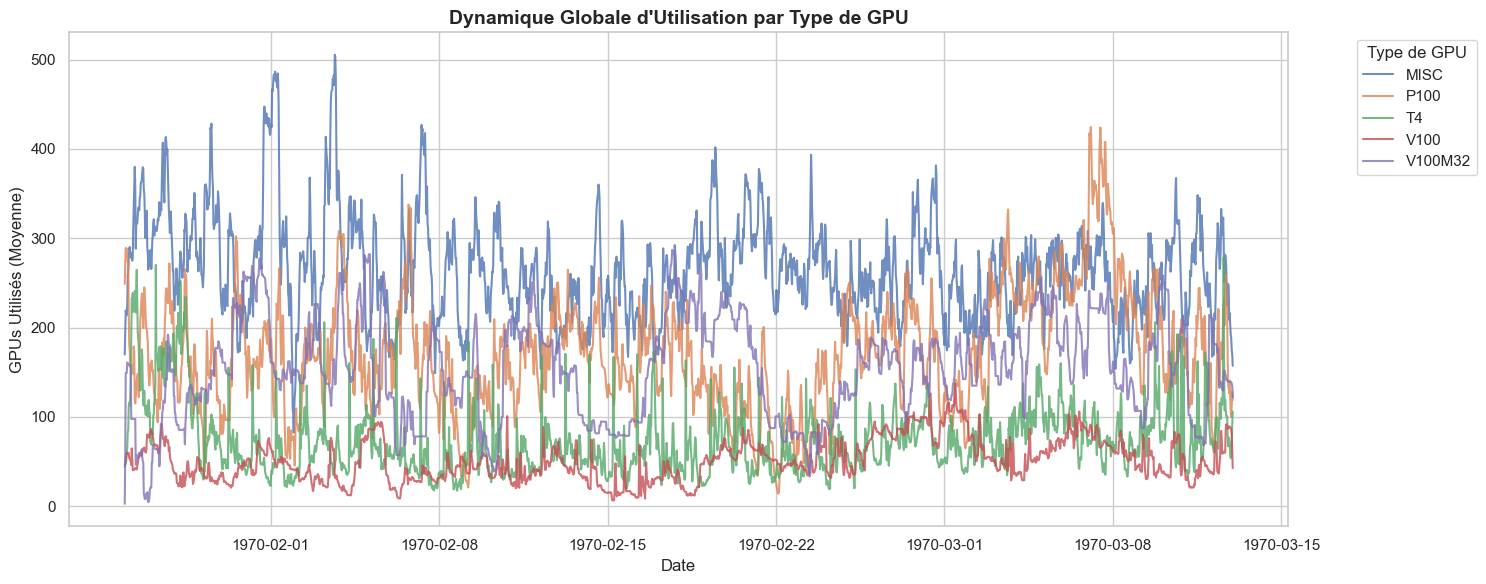

In [35]:
plt.figure(figsize=(15, 6))

# On trace l'utilisation moyenne, séparée par type de GPU (hue)
sns.lineplot(data=df, x='datetime', y='util_mean', hue='gpu_type', alpha=0.8, linewidth=1.5)

plt.title("Dynamique Globale d'Utilisation par Type de GPU", fontsize=14, fontweight='bold')
plt.ylabel("GPUs Utilisés (Moyenne)")
plt.xlabel("Date")
plt.legend(title='Type de GPU', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


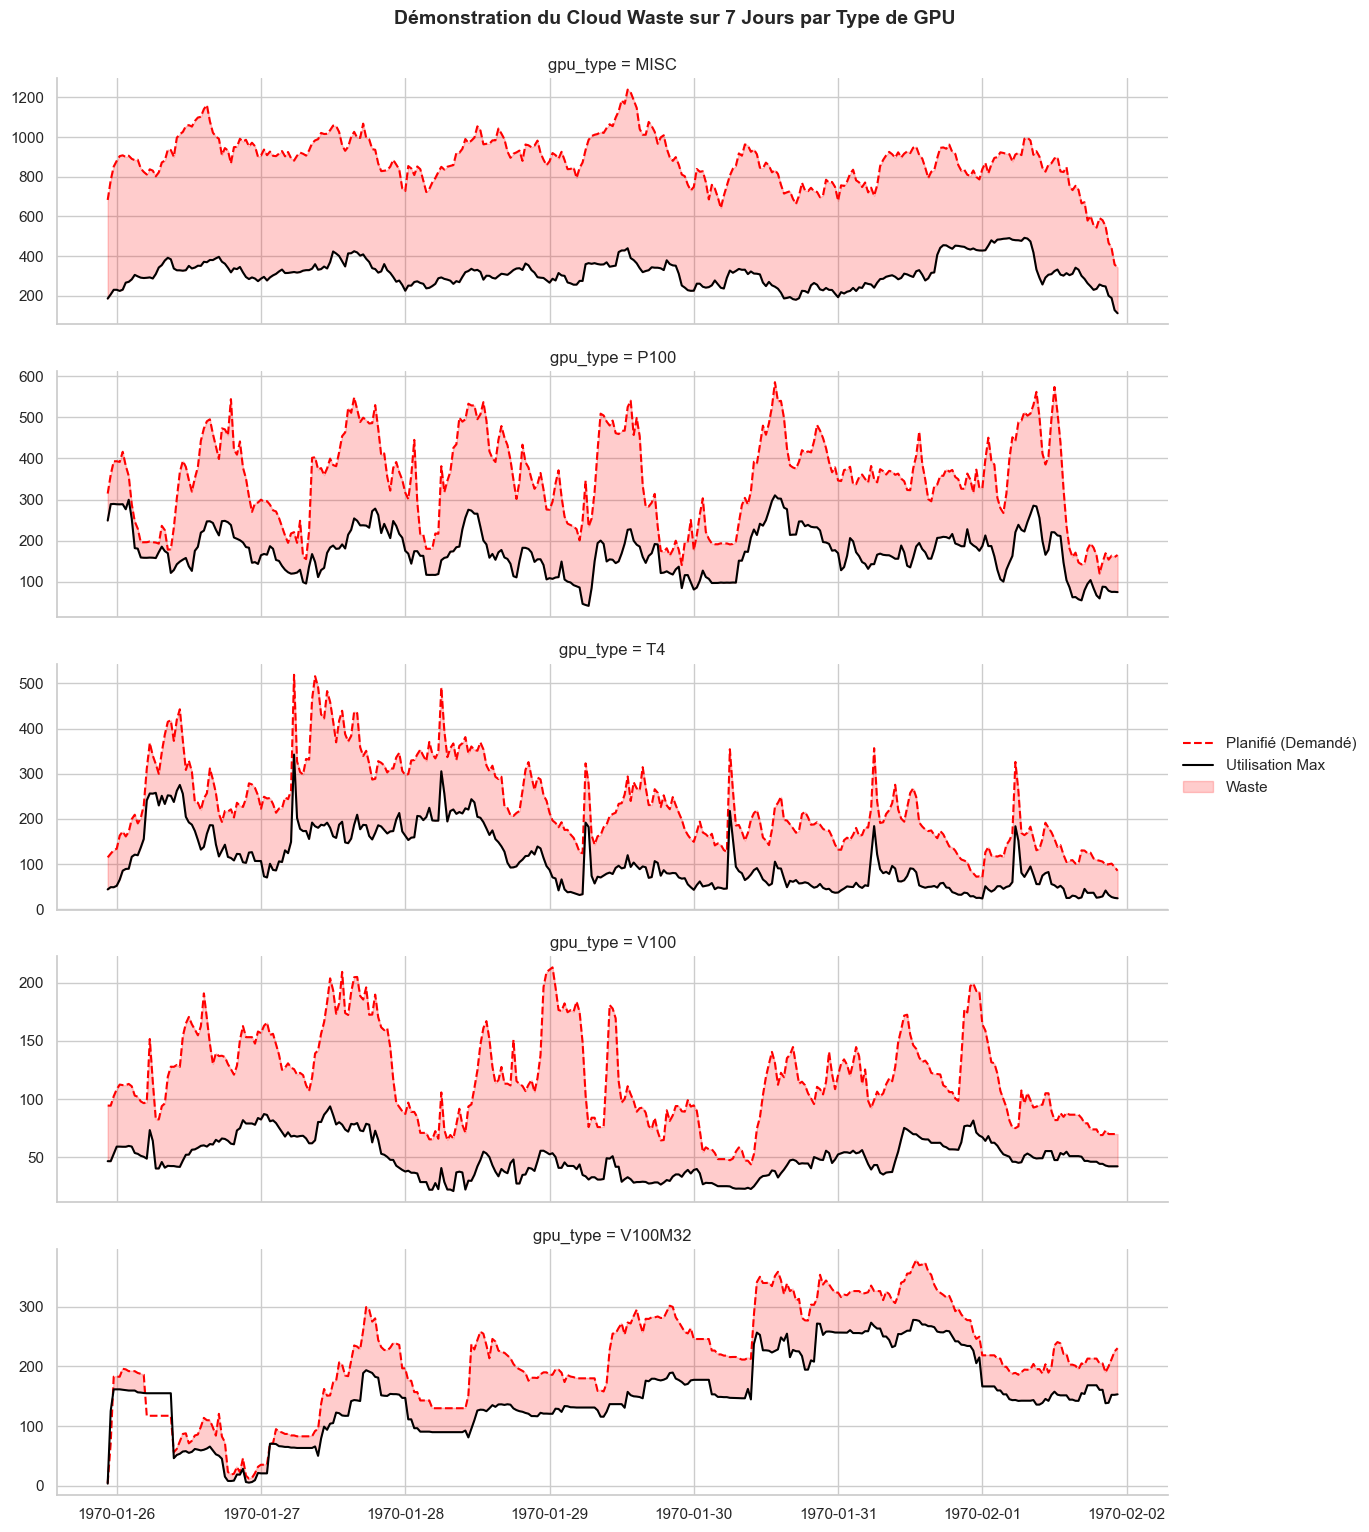

In [36]:
# %%
# On se concentre sur une semaine type (ex: les 7 premiers jours du dataset)
start_date = df['datetime'].min()
end_date = start_date + pd.Timedelta(days=7)
df_week = df[(df['datetime'] >= start_date) & (df['datetime'] <= end_date)]

# Création d'une grille : 1 ligne par GPU
g = sns.FacetGrid(df_week, row="gpu_type", height=3, aspect=4, sharey=False)

def plot_waste(data, **kwargs):
    plt.plot(data['datetime'], data['plan_mean'], label='Planifié (Demandé)', color='red', linestyle='--', linewidth=1.5)
    plt.plot(data['datetime'], data['util_max'], label='Utilisation Max', color='black', linewidth=1.5)
    plt.fill_between(data['datetime'], data['util_max'], data['plan_mean'], where=(data['plan_mean'] > data['util_max']), color='red', alpha=0.2, label='Waste')

g.map_dataframe(plot_waste)
g.add_legend()
g.fig.suptitle("Démonstration du Cloud Waste sur 7 Jours par Type de GPU", fontsize=14, fontweight='bold', y=1.02)
plt.show()

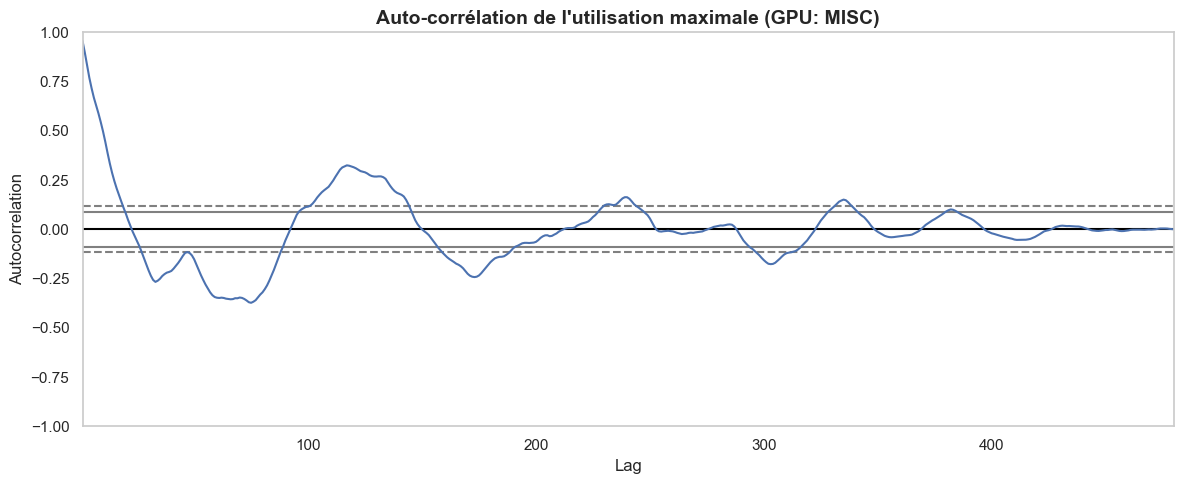

In [37]:
# %%
from pandas.plotting import autocorrelation_plot

# STRATÉGIE : On isole UN SEUL type de GPU et on s'assure qu'il est trié temporellement.
target_gpu = df['gpu_type'].unique()[0] # Change ceci par le nom de ton GPU principal si besoin
df_single_gpu = df[df['gpu_type'] == target_gpu].sort_values('datetime').set_index('datetime')

plt.figure(figsize=(12, 5))

# 480 pas de 30min = 10 jours pleins (48 * 10). Cette fois, la mathématique est vraie.
autocorrelation_plot(df_single_gpu['util_max'].head(480)) 

plt.title(f"Auto-corrélation de l'utilisation maximale (GPU: {target_gpu})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

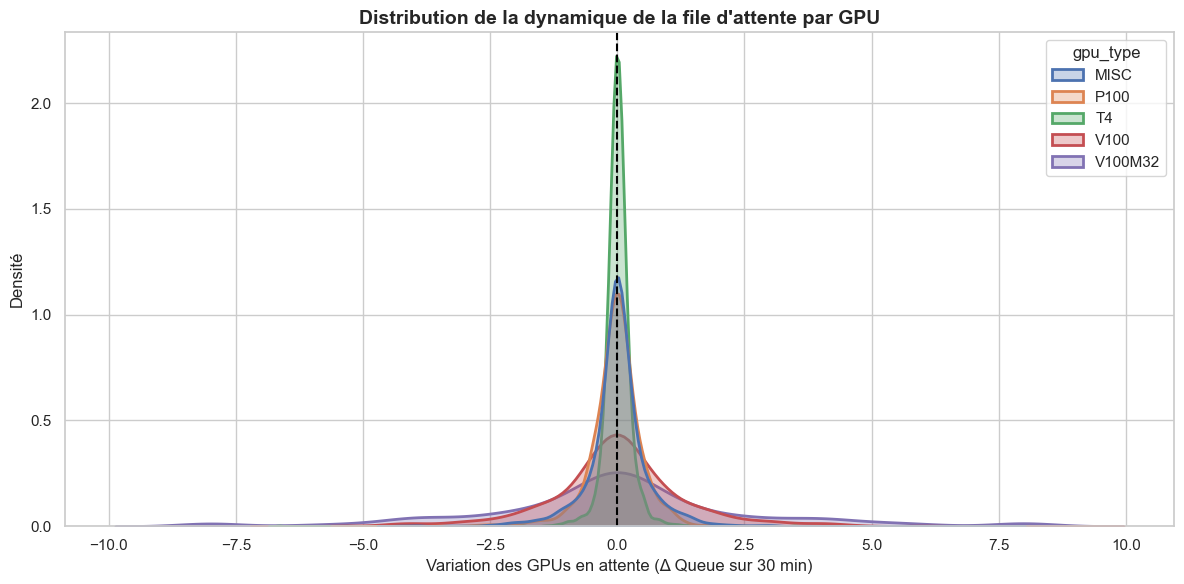

In [38]:
# %%
plt.figure(figsize=(12, 6))

# On filtre les moments où il y a une vraie dynamique (ignorer les zéros plats pour la lisibilité)
df_active_queue = df[df['queue_trend'] != 0]

sns.kdeplot(data=df_active_queue, x='queue_trend', hue='gpu_type', common_norm=False, fill=True, alpha=0.3, linewidth=2)

plt.title("Distribution de la dynamique de la file d'attente par GPU", fontsize=14, fontweight='bold')
plt.xlabel("Variation des GPUs en attente (Δ Queue sur 30 min)")
plt.ylabel("Densité")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [39]:
# %%
# 1. Chargement et Agrégation de la Capacité Physique
df_spec = pd.read_csv(os.path.join(BASE_DIR, 'data', 'raw', 'pai_machine_spec.csv'), header=None,
    names=['machine', 'gpu_type', 'cap_cpu', 'cap_mem', 'cap_gpu'])

# On gère les valeurs nulles exactement comme dans le pipeline
df_spec['gpu_type'] = df_spec['gpu_type'].fillna('MISC')

# On somme le nombre de GPUs par type
df_capacity = df_spec.groupby('gpu_type')['cap_gpu'].sum().reset_index()
df_capacity.rename(columns={'cap_gpu': 'total_capacity'}, inplace=True)

# Affichage clair de ton inventaire matériel
print("=== INVENTAIRE PHYSIQUE DU DATACENTER ===")
df_capacity['weight_pct'] = (df_capacity['total_capacity'] / df_capacity['total_capacity'].sum()) * 100
print(df_capacity.sort_values('total_capacity', ascending=False).to_string(index=False))

=== INVENTAIRE PHYSIQUE DU DATACENTER ===
gpu_type  total_capacity  weight_pct
    MISC            2240   33.224562
    P100            1596   23.672501
 V100M32            1080   16.018985
      T4             994   14.743400
    V100             832   12.340552
     CPU               0    0.000000


>>> Démarrage de l'Analyse Exploratoire FinOps...
[INFO] Données consolidées et métriques de saturation calculées.


C:\Users\piere\AppData\Local\Temp\ipykernel_4988\2571972668.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gpu_type', y='util_max_pct', palette="Set2")


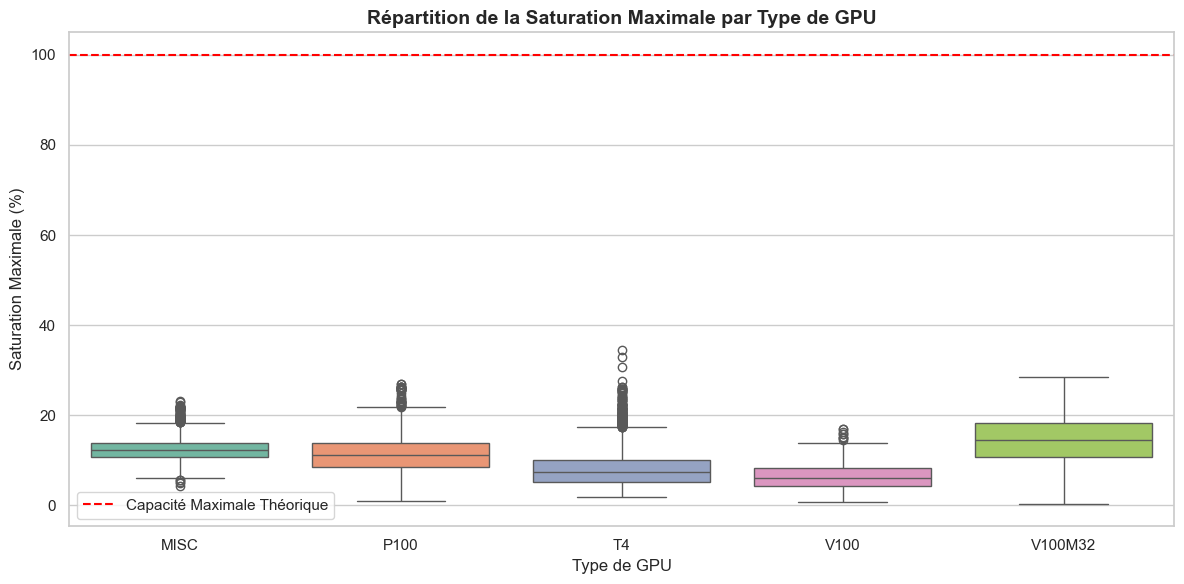

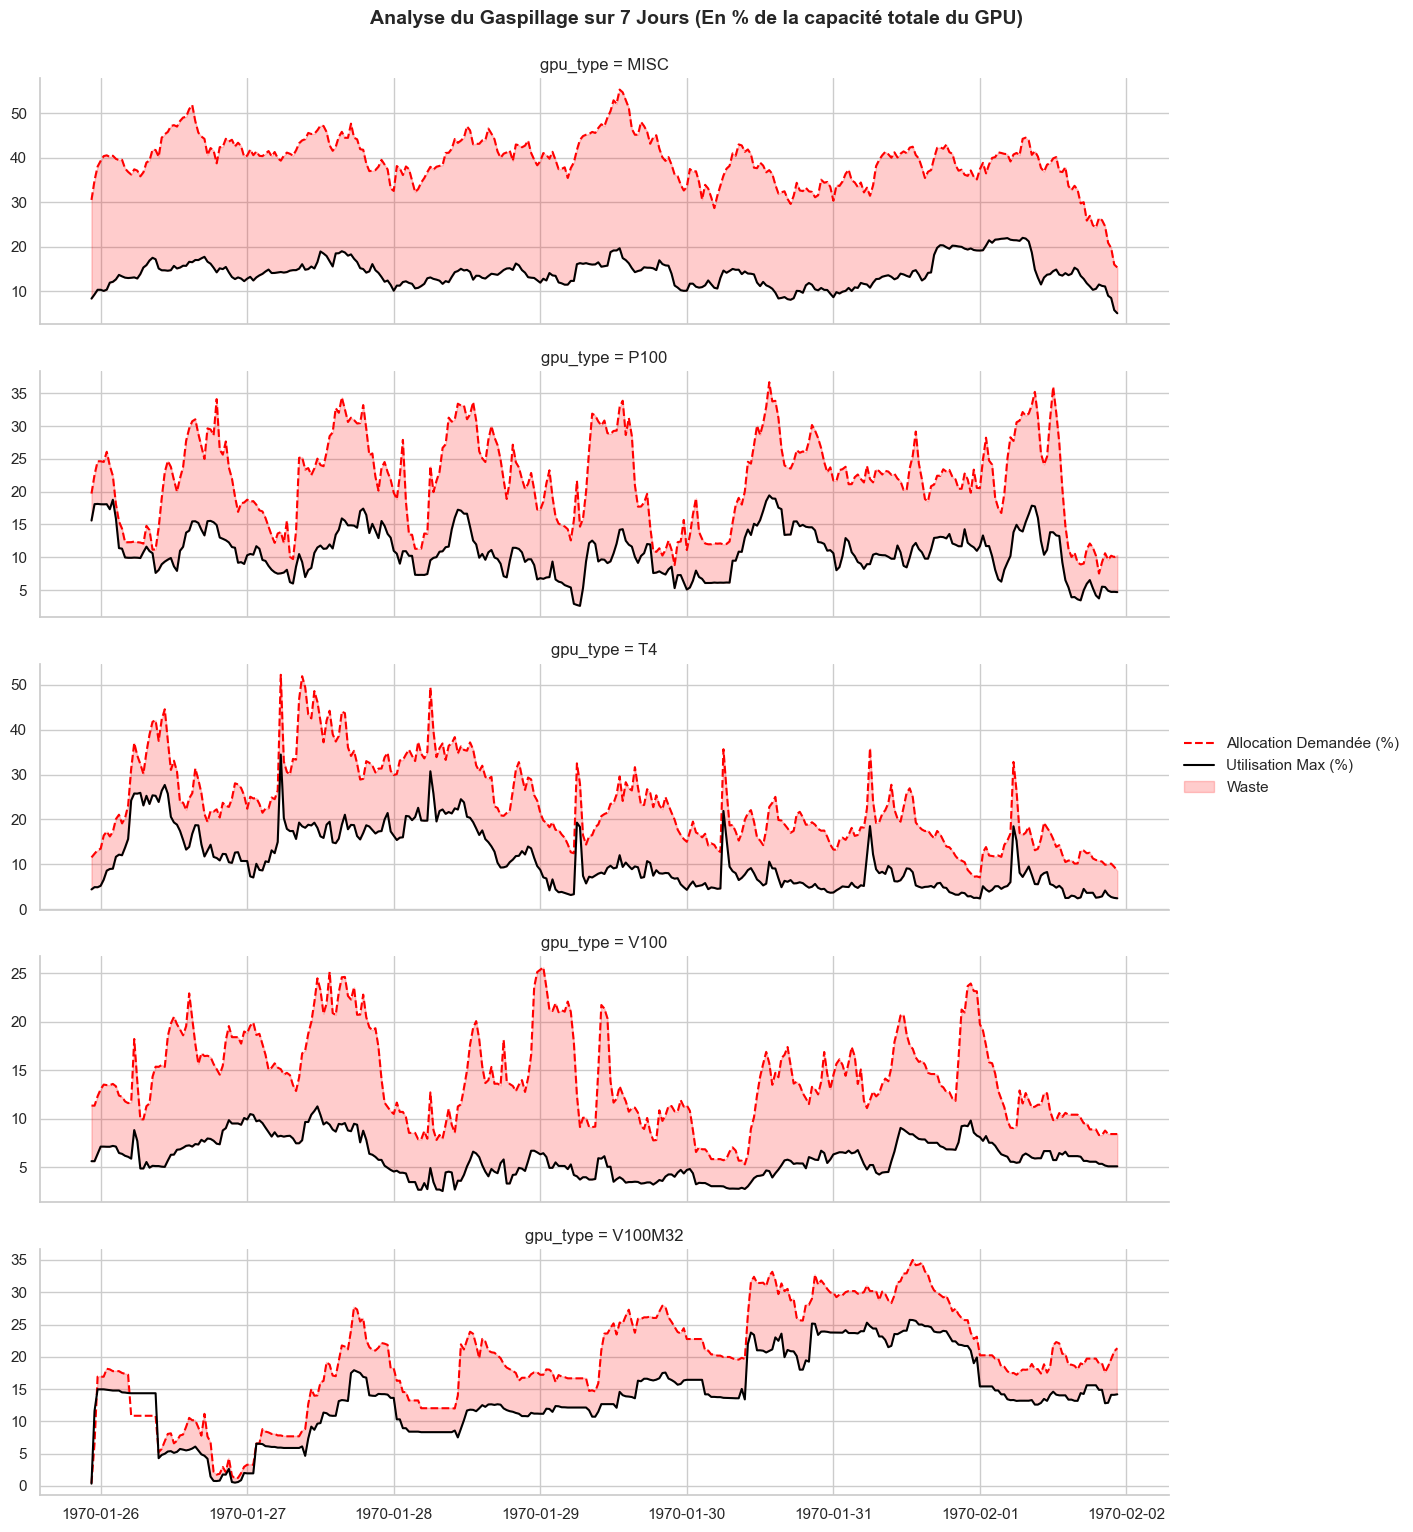

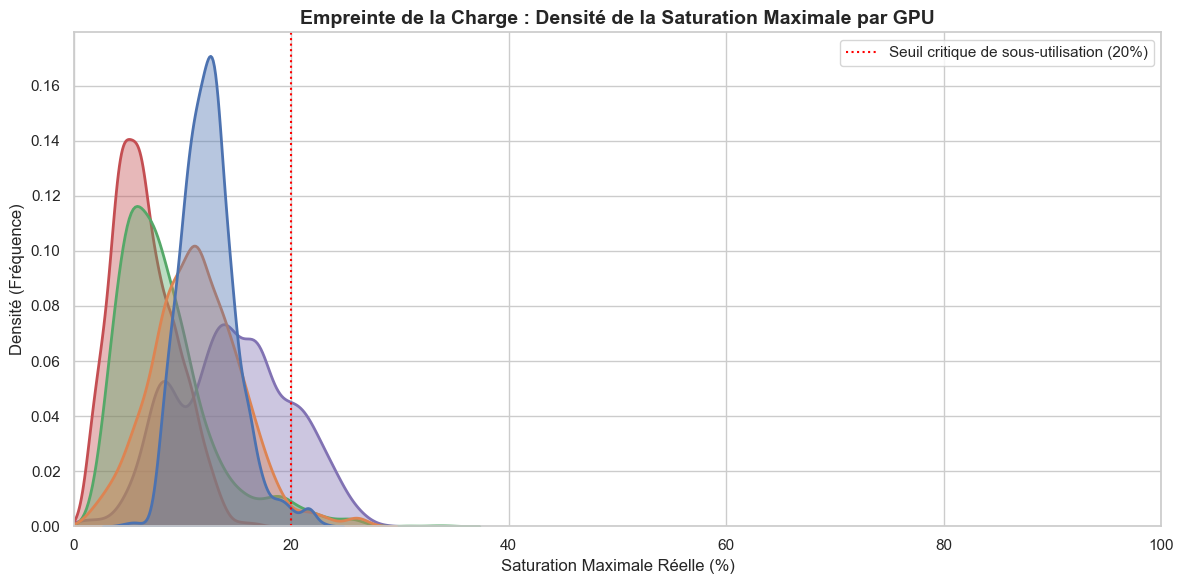

In [41]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# =================================================================
# 0. CONFIGURATION & ESTHÉTIQUE
# =================================================================
sns.set_theme(style="whitegrid")
BASE_DIR = Path.cwd().parent
PATH_PROCESSED = os.path.join(BASE_DIR, 'data', 'processed', 'processed_jobs.csv')
PATH_SPEC = os.path.join(BASE_DIR, 'data', 'raw', 'pai_machine_spec.csv')

print(">>> Démarrage de l'Analyse Exploratoire FinOps...")

# =================================================================
# 1. CHARGEMENT ET FUSION DES RÉALITÉS (TEMPS + MATÉRIEL)
# =================================================================
# A. Données Temporelles
df = pd.read_csv(PATH_PROCESSED, parse_dates=['datetime'])

# B. Données Matérielles (Inventaire)
df_spec = pd.read_csv(PATH_SPEC, header=None, names=['machine', 'gpu_type', 'cap_cpu', 'cap_mem', 'cap_gpu'])
df_spec['gpu_type'] = df_spec['gpu_type'].fillna('MISC')
df_capacity = df_spec.groupby('gpu_type')['cap_gpu'].sum().reset_index()
df_capacity.rename(columns={'cap_gpu': 'total_capacity'}, inplace=True)

# C. La Jointure Stratégique
df = pd.merge(df, df_capacity[['gpu_type', 'total_capacity']], on='gpu_type', how='left')

# On exclut les CPUs purs s'ils remontent dans l'analyse GPU pour éviter de polluer les stats
df = df[df['gpu_type'] != 'CPU'].copy()

# =================================================================
# 2. CRÉATION DES MÉTRIQUES STRATÉGIQUES (POURCENTAGES)
# =================================================================
# Calcul du pourcentage de saturation réel face à la capacité physique
df['util_mean_pct'] = (df['util_mean'] / df['total_capacity']) * 100
df['util_max_pct'] = (df['util_max'] / df['total_capacity']) * 100
df['plan_mean_pct'] = (df['plan_mean'] / df['total_capacity']) * 100

print("[INFO] Données consolidées et métriques de saturation calculées.")

# =================================================================
# 3. VISUALISATION 1 : LE BILAN DE SANTÉ DU CLUSTER (SATURATION)
# =================================================================
plt.figure(figsize=(12, 6))

# Un Boxplot nous montre immédiatement la médiane et les valeurs extrêmes d'utilisation
sns.boxplot(data=df, x='gpu_type', y='util_max_pct', palette="Set2")

plt.title("Répartition de la Saturation Maximale par Type de GPU", fontsize=14, fontweight='bold')
plt.xlabel("Type de GPU")
plt.ylabel("Saturation Maximale (%)")
plt.axhline(y=100, color='red', linestyle='--', label='Capacité Maximale Théorique')
plt.legend()
plt.tight_layout()
plt.show()

# =================================================================
# 4. VISUALISATION 2 : LE DIAGNOSTIC DU GASPILLAGE (CLOUD WASTE)
# =================================================================
# On extrait les 7 premiers jours de données pour avoir un échantillon lisible
start_date = df['datetime'].min()
end_date = start_date + pd.Timedelta(days=7)
df_week = df[(df['datetime'] >= start_date) & (df['datetime'] <= end_date)]

# Création d'une grille pour analyser chaque GPU indépendamment
g = sns.FacetGrid(df_week, row="gpu_type", height=3, aspect=4, sharey=False)

def plot_waste_pct(data, **kwargs):
    # On trace les allocations VS l'utilisation réelle EN POURCENTAGE
    plt.plot(data['datetime'], data['plan_mean_pct'], label='Allocation Demandée (%)', color='red', linestyle='--', linewidth=1.5)
    plt.plot(data['datetime'], data['util_max_pct'], label='Utilisation Max (%)', color='black', linewidth=1.5)
    
    # La zone rouge représente l'argent brûlé : GPU réservé mais non utilisé
    plt.fill_between(data['datetime'], data['util_max_pct'], data['plan_mean_pct'], 
                     where=(data['plan_mean_pct'] > data['util_max_pct']), 
                     color='red', alpha=0.2, label='Waste')

g.map_dataframe(plot_waste_pct)
g.add_legend()
g.fig.suptitle("Analyse du Gaspillage sur 7 Jours (En % de la capacité totale du GPU)", fontsize=14, fontweight='bold', y=1.02)
plt.show()

# =================================================================
# 5. VISUALISATION 3 : L'EMPREINTE DE LA CHARGE (DENSITÉ D'UTILISATION)
# =================================================================
plt.figure(figsize=(12, 6))

# On trace la densité de la saturation maximale (util_max_pct)
# On ignore les moments où l'utilisation est strictement à 0 pour mieux voir la forme de la charge active
df_active_util = df[df['util_max_pct'] > 0]

sns.kdeplot(data=df_active_util, x='util_max_pct', hue='gpu_type', 
            common_norm=False, fill=True, alpha=0.4, linewidth=2, clip=(0, 100))

plt.title("Empreinte de la Charge : Densité de la Saturation Maximale par GPU", fontsize=14, fontweight='bold')
plt.xlabel("Saturation Maximale Réelle (%)")
plt.ylabel("Densité (Fréquence)")
plt.axvline(x=20, color='red', linestyle=':', label='Seuil critique de sous-utilisation (20%)')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()